In [1]:
# Реализуйте высокочастотную фильтрацию на основе ядра Гаусса
# Реализуйте удаление периодического шума

# 1. Реализуйте высокочастотную фильтрацию на основе ядра Гаусса

In [2]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
from skimage.feature import peak_local_max

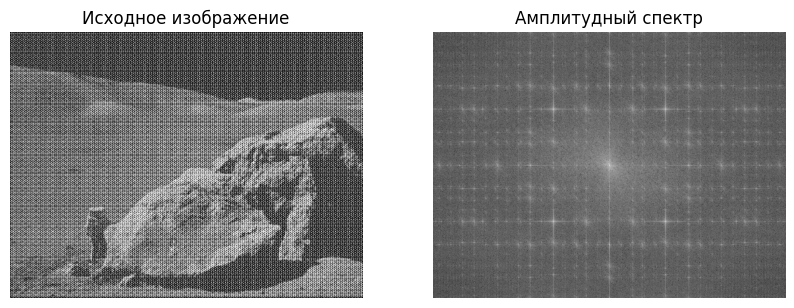

In [4]:
img = cv.imread('periodic_noise.jpg', cv.IMREAD_GRAYSCALE)

dft = cv.dft(np.float32(img), flags=cv.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
magnitude_spectrum = 20 * np.log(
    cv.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1
)

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Амплитудный спектр')
plt.axis('off')

plt.show()

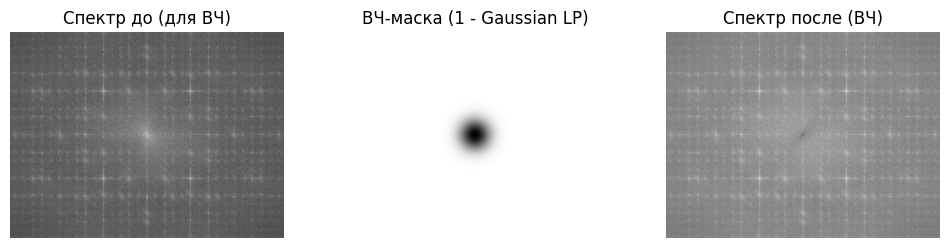

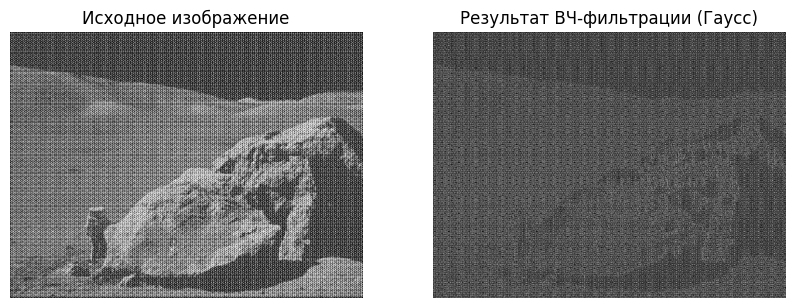

In [5]:
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
sigma = 30

x = np.arange(0, cols, 1)
y = np.arange(0, rows, 1)
X, Y = np.meshgrid(x, y)
gaussian_mask = np.exp(-((X - ccol) ** 2 + (Y - crow) ** 2) / (2 * sigma ** 2))
high_pass_mask = 1 - gaussian_mask

dft_shift_high_pass = dft_shift * high_pass_mask[:, :, np.newaxis]

magnitude_spectrum_hp = 20 * np.log(
    cv.magnitude(dft_shift_high_pass[:, :, 0], dft_shift_high_pass[:, :, 1]) + 1
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Спектр до (для ВЧ)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(high_pass_mask, cmap='gray')
plt.title('ВЧ-маска (1 - Gaussian LP)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(magnitude_spectrum_hp, cmap='gray')
plt.title('Спектр после (ВЧ)')
plt.axis('off')

plt.show()

f_ishift_high_pass = np.fft.ifftshift(dft_shift_high_pass)
img_back_high_pass = cv.idft(f_ishift_high_pass)
img_back_high_pass = cv.magnitude(img_back_high_pass[:, :, 0], img_back_high_pass[:, :, 1])
img_back_high_pass = cv.normalize(img_back_high_pass, None, 0, 255, cv.NORM_MINMAX)

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_back_high_pass, cmap='gray')
plt.title('Результат ВЧ-фильтрации (Гаусс)')
plt.axis('off')

plt.show()

# 2. Реализуйте удаление периодического шума

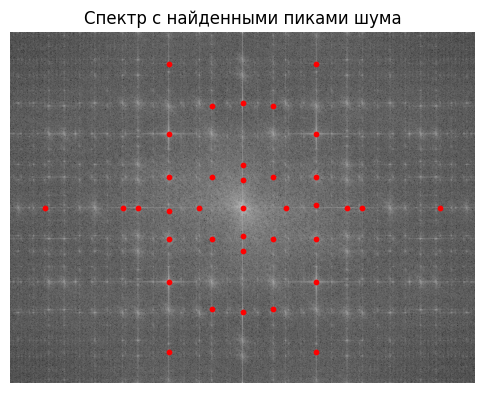

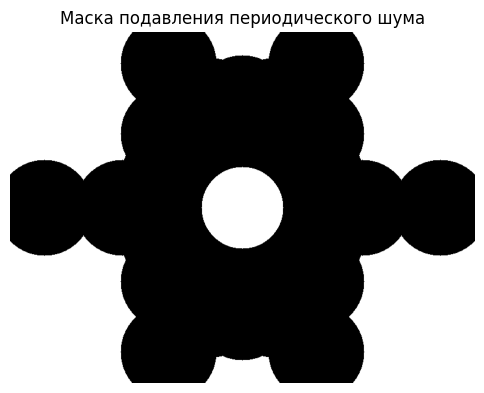

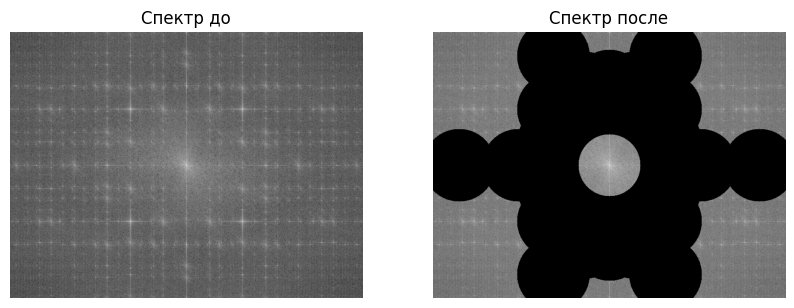

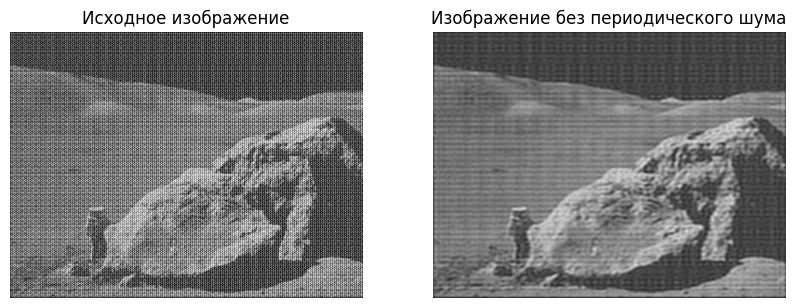

In [ ]:
min_distance = 10
threshold_abs = 270
noise_coords = peak_local_max(
    magnitude_spectrum,
    min_distance=min_distance,
    threshold_abs=threshold_abs
)

mask_noise = np.ones_like(dft_shift)
radius = 81

for coord in noise_coords:
    cv.circle(mask_noise, (coord[1], coord[0]), radius, (0, 0), -1)

cv.circle(mask_noise, (ccol, crow), radius + 12, (0, 0), -1)
cv.circle(mask_noise, (ccol, crow), radius - 12, (1, 1), -1)

plt.figure(figsize=(6, 5))
plt.imshow(magnitude_spectrum, cmap='gray')
if noise_coords is not None and len(noise_coords) > 0:
    plt.scatter(noise_coords[:, 1], noise_coords[:, 0], c='r', s=10)
plt.title('Спектр с найденными пиками шума')
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(mask_noise[:, :, 0], cmap='gray')
plt.title('Маска подавления периодического шума')
plt.axis('off')
plt.show()

dft_shift_noise_removed = dft_shift * mask_noise

magnitude_spectrum_clean = 20 * np.log(
    cv.magnitude(dft_shift_noise_removed[:, :, 0], dft_shift_noise_removed[:, :, 1]) + 1
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Спектр до')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum_clean, cmap='gray')
plt.title('Спектр после')
plt.axis('off')

plt.show()

f_ishift_noise_removed = np.fft.ifftshift(dft_shift_noise_removed)
img_back_noise_removed = cv.idft(f_ishift_noise_removed)
img_back_noise_removed = cv.magnitude(img_back_noise_removed[:, :, 0], img_back_noise_removed[:, :, 1])
img_back_noise_removed = cv.normalize(img_back_noise_removed, None, 0, 255, cv.NORM_MINMAX)

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_back_noise_removed, cmap='gray')
plt.title('Изображение без периодического шума')
plt.axis('off')

plt.show()